# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [137]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import math

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [138]:
#Importation du fichier population.csv
population = pd.read_csv('.\\DAN-P4-FAO\\population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('.\\DAN-P4-FAO\\dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('.\\DAN-P4-FAO\\aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('.\\DAN-P4-FAO\\sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [139]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [140]:
#Consulter le nombre de colonnes
if len(population.columns) > 1:
    colonnes = ", ".join(population.columns[:-1]) + " et " + population.columns[-1]
elif len(population.columns) == 1:
    colonnes = population.columns[0]
else:
    colonnes = ""
print("Le tableau comporte {} colonne(s): {}.".format(population.shape[1], colonnes))
#La nature des données dans chacune des colonnes
for k,v in population.dtypes.items():
    print("La colonne {} contient des données de nature {}".format(k,v))
#Le nombre de valeurs présentes dans chacune des colonnes
for k,v in population.count().items():
    print("La colonne {} contient {} données".format(k,v))

Le tableau comporte 3 colonne(s): Zone, Année et Valeur.
La colonne Zone contient des données de nature str
La colonne Année contient des données de nature int64
La colonne Valeur contient des données de nature float64
La colonne Zone contient 1416 données
La colonne Année contient 1416 données
La colonne Valeur contient 1416 données


In [141]:
#Affichage les 5 premières lignes de la table
population.head(5)

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [142]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur'] * 1000

In [143]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={'Valeur':'Population'})

In [144]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head(5)

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [145]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [146]:
#Consulter le nombre de colonnes
if len(dispo_alimentaire.columns) > 1:
    colonnes = ", ".join(dispo_alimentaire.columns[:-1]) + " et " + dispo_alimentaire.columns[-1]
elif len(population.columns) == 1:
    colonnes = dispo_alimentaire.columns[0]
else:
    colonnes = ""
print("Le tableau comporte {} colonne(s): {}.".format(dispo_alimentaire.shape[1], colonnes))

Le tableau comporte 18 colonne(s): Zone, Produit, Origine, Aliments pour animaux, Autres Utilisations, Disponibilité alimentaire (Kcal/personne/jour), Disponibilité alimentaire en quantité (kg/personne/an), Disponibilité de matière grasse en quantité (g/personne/jour), Disponibilité de protéines en quantité (g/personne/jour), Disponibilité intérieure, Exportations - Quantité, Importations - Quantité, Nourriture, Pertes, Production, Semences, Traitement et Variation de stock.


In [147]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [148]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [149]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire.loc[:, ['Aliments pour animaux', 'Autres Utilisations', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']] = dispo_alimentaire[['Aliments pour animaux', 'Autres Utilisations', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']] * 1000000

In [150]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [151]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [152]:
#Consulter le nombre de colonnes
if len(aide_alimentaire.columns) > 1:
    colonnes = ", ".join(aide_alimentaire.columns[:-1]) + " et " + aide_alimentaire.columns[-1]
elif len(population.columns) == 1:
    colonnes = aide_alimentaire.columns[0]
else:
    colonnes = ""
print("Le tableau comporte {} colonne(s): {}.".format(aide_alimentaire.shape[1], colonnes))

Le tableau comporte 4 colonne(s): Pays bénéficiaire, Année, Produit et Valeur.


In [153]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [154]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'})

In [155]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur'] * 1000

In [156]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [157]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [158]:
#Consulter le nombre de colonnes
if len(sous_nutrition.columns) > 1:
    colonnes = ", ".join(sous_nutrition.columns[:-1]) + " et " + sous_nutrition.columns[-1]
elif len(population.columns) == 1:
    colonnes = sous_nutrition.columns[0]
else:
    colonnes = ""
print("Le tableau comporte {} colonne(s): {}.".format(sous_nutrition.shape[1], colonnes))

Le tableau comporte 3 colonne(s): Zone, Année et Valeur.


In [159]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [160]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')

In [161]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition = sous_nutrition.fillna(0)

In [162]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={'Valeur':'Sous_nutrition'})

In [163]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['Sous_nutrition'] = sous_nutrition['Sous_nutrition'] * 1000000

In [164]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [165]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
### replacement des 3 années par la valeur centrale, dans la colonne 'Année' de sous_nutrition
sous_nutrition[['Début', 'Fin']] = sous_nutrition['Année'].str.split('-', expand=True)
sous_nutrition['Début'] = sous_nutrition['Début'].astype(int)
sous_nutrition['Fin'] = sous_nutrition['Fin'].astype(int)
sous_nutrition['Année'] = (sous_nutrition['Début'] + sous_nutrition['Fin']) // 2
sous_nutrition = sous_nutrition.drop(columns=['Début', 'Fin'])
### jointure de population et sous_nutrition
nombre_sous_nutrition = pd.merge(population, sous_nutrition, on=['Zone', 'Année'], how='inner')
### restriction à l'année 2017
nombre_sous_nutrition = nombre_sous_nutrition[nombre_sous_nutrition['Année'] == 2017]

In [166]:
#Affichage du dataset
nombre_sous_nutrition

,Zone,Année,Population,Sous_nutrition
4,Afghanistan,2017,36296113.0,10500000.0
10,Afrique du Sud,2017,57009756.0,3100000.0
16,Albanie,2017,2884169.0,100000.0
22,Algérie,2017,41389189.0,1300000.0
28,Allemagne,2017,82658409.0,0.0
...,...,...,...,...
1192,Venezuela (République bolivarienne du),2017,29402484.0,8000000.0
1198,Viet Nam,2017,94600648.0,6500000.0
1204,Yémen,2017,27834819.0,0.0
1210,Zambie,2017,16853599.0,0.0


In [167]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
nb_total = nombre_sous_nutrition['Population'].sum()
nb_sous_nutrition = nombre_sous_nutrition['Sous_nutrition'].sum()
print("Il y a {} personnes en sous-nutrition dans le monde, pour une population totale de {}, soit {}%".format(nb_sous_nutrition, nb_total, nb_sous_nutrition/nb_total*100))

Il y a 535700000.0 personnes en sous-nutrition dans le monde, pour une population totale de 7543798779.0, soit 7.1011968332354165%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [168]:
#Combien mange en moyenne un être humain ?
nb_kcal = 2600
# Source => Document de fao.org présenté en Mars 1981 : en ignorant les enfants, donc les besoins sont moindres, et utilisant les standards homme en forme à 65kg et femme en forme à 55kg, on a 3000 pour les hommes et 2200 pour les femmes. Ce qui donne une approximation de 2600 par personne

In [169]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population2017 = population[population['Année'] == 2017] ### filtrage sur 2017, dispo_alimentaire ne concerne que cette année-là
population2017 = population2017.drop('Année', axis = 1)
nourriture_personne = pd.merge(population2017, dispo_alimentaire, on='Zone', how='inner')

In [170]:
#Affichage du nouveau dataframe
nourriture_personne

,Zone,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,14236595.0,Viande de Suides,animale,0.0,0.0,24.0,2.65,2.25,0.83,37000000.0,0.0,6000000.0,37000000.0,0.0,32000000.0,0.0,0.0,0.0
15412,Zimbabwe,14236595.0,Viande de Volailles,animale,0.0,0.0,17.0,4.97,1.05,1.69,70000000.0,0.0,6000000.0,70000000.0,0.0,64000000.0,0.0,0.0,0.0
15413,Zimbabwe,14236595.0,"Viande, Autre",animale,0.0,1000000.0,7.0,2.29,0.21,1.12,34000000.0,3000000.0,1000000.0,32000000.0,0.0,36000000.0,0.0,0.0,0.0
15414,Zimbabwe,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,0.00,4000000.0,0.0,2000000.0,4000000.0,0.0,2000000.0,0.0,0.0,0.0


In [171]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
nourriture_personne['dispo_kcal'] = nourriture_personne['Disponibilité alimentaire (Kcal/personne/jour)'] * nourriture_personne['Population']

In [172]:
#Calcul du nombre d'humains pouvant être nourris
nourriture_personne['pop_nourrissable'] = nourriture_personne['dispo_kcal'] / nb_kcal
humain_nourrissable = nourriture_personne['pop_nourrissable'].sum()
nourriture_personne = nourriture_personne.drop('pop_nourrissable', axis = 1)

print("Avec l'entièreté des ressources de la planète, on peut nourrir {} humains par jour, soit {}% de la population mondiale de 2017".format(math.floor(humain_nourrissable), math.floor(humain_nourrissable)/population2017['Population'].sum()*100))

Avec l'entièreté des ressources de la planète, on peut nourrir 8045763318 humains par jour, soit 106.59274463969577% de la population mondiale de 2017


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [173]:
#Transfert des données avec les végétaux dans un nouveau dataframe
nourriture_personne_vege = nourriture_personne.loc[nourriture_personne['Origine'] == "vegetale"]
nourriture_personne_vege

,Zone,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
1,Afghanistan,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,145184452.0
6,Afghanistan,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000000.0,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Zimbabwe,14236595.0,Sésame,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15407,Zimbabwe,14236595.0,Thé,vegetale,0.0,0.0,1.0,0.54,0.00,0.15,8000000.0,12000000.0,1000000.0,8000000.0,0.0,19000000.0,0.0,0.0,0.0,14236595.0
15408,Zimbabwe,14236595.0,Tomates,vegetale,0.0,0.0,1.0,1.80,0.01,0.04,27000000.0,0.0,3000000.0,25000000.0,1000000.0,24000000.0,0.0,0.0,0.0,14236595.0
15414,Zimbabwe,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,0.00,4000000.0,0.0,2000000.0,4000000.0,0.0,2000000.0,0.0,0.0,0.0,14236595.0


In [174]:
#Calcul du nombre de kcal disponible pour les végétaux
nb_vege_kcal = nourriture_personne_vege['dispo_kcal'].sum()

In [175]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
humain_nourrissable_vege = nb_vege_kcal / nb_kcal
print("Avec l'entièreté des ressources végétales de la planète, on peut nourrir {} humains par jour, soit {}% de la population mondiale de 2017".format(math.floor(humain_nourrissable_vege), math.floor(humain_nourrissable_vege)/population2017['Population'].sum()*100))

Avec l'entièreté des ressources végétales de la planète, on peut nourrir 6638755465 humains par jour, soit 87.95227227514745% de la population mondiale de 2017


print("Avec l'entièreté des ressources de la planètes, on peut nourrir {} humains par jour, soit {}% de la population mondiale de 2017".format(math.floor(humain_nourrissable), math.floor(humain_nourrissable)/population2017['Population'].sum()*100))<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [176]:
#Calcul de la disponibilité totale intérieure
dti = dispo_alimentaire['Disponibilité intérieure'].sum()

In [177]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,
colonnes_intéressantes = ['Aliments pour animaux', 'Pertes', 'Nourriture']

for col in colonnes_intéressantes:
    total_col = dispo_alimentaire[col].sum()
    part = (total_col / dti) * 100

    print("Les {} représentent {}, soit {}% de la disponibilité totale intérieure".format(col, total_col, total_col/dti*100))

Les Aliments pour animaux représentent 1304245000000.0, soit 13.242418464261426% de la disponibilité totale intérieure
Les Pertes représentent 453698000000.0, soit 4.606541541196999% de la disponibilité totale intérieure
Les Nourriture représentent 4876258000000.0, soit 49.51021393657058% de la disponibilité totale intérieure


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [178]:
#Création d'une liste avec toutes les variables
liste_cereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle", "Avoine", "Millet", "Sorgho", "Céréales, Autres"]

In [179]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_cereales = dispo_alimentaire.loc[dispo_alimentaire['Produit'].isin(liste_cereales)]

In [180]:
#Affichage de la proportion d'alimentation animale
total_dispo_cereales = dispo_cereales['Disponibilité intérieure'].sum()
total_cereales_animaux = dispo_cereales['Aliments pour animaux'].sum()
part_animaux_cereales = (total_cereales_animaux / total_dispo_cereales) * 100
print("{} tonnes de céréales sont dédiées aux animaux, soit {}%".format(total_cereales_animaux, part_animaux_cereales))

873535000000.0 tonnes de céréales sont dédiées aux animaux, soit 36.291456706047654%


In [181]:
#Affichage de la proportion d'alimentation humaine
total_cereales_nourriture = dispo_cereales['Nourriture'].sum()
part_nourriture_cereales = (total_cereales_nourriture / total_dispo_cereales) * 100
print("{} tonnes de céréales sont dédiées aux humains, soit {}%".format(total_cereales_nourriture, part_nourriture_cereales))

1029010000000.0 tonnes de céréales sont dédiées aux humains, soit 42.75074480712289%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [182]:
#Création de la colonne proportion par pays
nombre_sous_nutrition['Proportion'] = nombre_sous_nutrition['Sous_nutrition'] / nombre_sous_nutrition['Population'] * 100

In [183]:
#affichage après trie des 10 pires pays
nombre_sous_nutrition.sort_values('Proportion', ascending=False).head(10)

,Zone,Année,Population,Sous_nutrition,Proportion
472,Haïti,2017,10982366.0,5300000.0,48.259182
946,République populaire démocratique de Corée,2017,25429825.0,12000000.0,47.188685
652,Madagascar,2017,25570512.0,10500000.0,41.062924
622,Libéria,2017,4702226.0,1800000.0,38.279742
604,Lesotho,2017,2091534.0,800000.0,38.249438
1102,Tchad,2017,15016753.0,5700000.0,37.957606
970,Rwanda,2017,11980961.0,4200000.0,35.055619
730,Mozambique,2017,28649018.0,9400000.0,32.810898
1120,Timor-Leste,2017,1243258.0,400000.0,32.173531
4,Afghanistan,2017,36296113.0,10500000.0,28.928718


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [184]:
#calcul du total de l'aide alimentaire par pays
top_aide = aide_alimentaire.groupby('Zone')[['Valeur']].sum()

In [185]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
top_aide.sort_values(by='Valeur', ascending=False).head(10)

,Valeur
Zone,
République arabe syrienne,1858943000
Éthiopie,1381294000
Yémen,1206484000
Soudan du Sud,695248000
Soudan,669784000
Kenya,552836000
Bangladesh,348188000
Somalie,292678000
République démocratique du Congo,288502000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [186]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
top5_pays = aide_alimentaire.groupby('Zone')['Valeur'].sum().sort_values(ascending=False).head(5).index

evolution_aide = aide_alimentaire[aide_alimentaire['Zone'].isin(top5_pays)]
evolution_aide = evolution_aide.groupby(['Zone', 'Année'])[['Valeur']].sum().reset_index()

In [187]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficié de l'aide alimentaire
top5_liste = top5_pays.tolist()
print("Les 5 pays prioritaires sont :", top5_liste)

Les 5 pays prioritaires sont : ['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [188]:
#On filtre sur le dataframe avec notre liste
top5_pays = aide_alimentaire[aide_alimentaire['Zone'].isin(top5_liste)]
evolution_aide = top5_pays.groupby(['Zone', 'Année'])[['Valeur']].sum().reset_index()

In [189]:
# Affichage des pays avec l'aide alimentaire par année
evolution_pivot = evolution_aide.pivot(index='Zone', columns='Année', values='Valeur')
evolution_pivot['Total'] = evolution_pivot.sum(axis=1)
evolution_pivot.sort_values(by='Total', ascending=False)

Année,2013,2014,2015,2016,Total
Zone,,,,,
République arabe syrienne,563566000.0,651870000.0,524949000.0,118558000.0,1.858943e+09
Éthiopie,591404000.0,586624000.0,203266000.0,NaN,1.381294e+09
Yémen,264764000.0,103840000.0,372306000.0,465574000.0,1.206484e+09
Soudan du Sud,196330000.0,450610000.0,48308000.0,NaN,6.952480e+08
Soudan,330230000.0,321904000.0,17650000.0,NaN,6.697840e+08


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [190]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pays = dispo_alimentaire.groupby('Zone')[['Disponibilité alimentaire (Kcal/personne/jour)']].sum()

In [191]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
top_10_faible_dispo = dispo_par_pays.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=True).head(10)
top_10_faible_dispo

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
République populaire démocratique de Corée,2093.0
Tchad,2109.0
Zimbabwe,2113.0
Ouganda,2126.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [192]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
top_10_forte_dispo = dispo_par_pays.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10)
top_10_forte_dispo

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
Autriche,3770.0
Belgique,3737.0
Turquie,3708.0
États-Unis d'Amérique,3682.0
Israël,3610.0
Irlande,3602.0
Italie,3578.0
Luxembourg,3540.0
Égypte,3518.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [193]:
#création d'un dataframe avec uniquement la Thaïlande
df_thailande = dispo_alimentaire[dispo_alimentaire['Zone'] == 'Thaïlande']
df_thailande_manioc = df_thailande[df_thailande['Produit'] == 'Manioc']

In [194]:
#Calcul de la sous nutrition en Thaïlande
sn_thailande = nombre_sous_nutrition[nombre_sous_nutrition['Zone'] == 'Thaïlande']
sn_thailande

,Zone,Année,Population,Sous_nutrition,Proportion
1114,Thaïlande,2017,69209810.0,6200000.0,8.958268


In [195]:
# On calcule la proportion exportée en fonction de la proportion
df_thailande_manioc = df_thailande[df_thailande['Produit'] == 'Manioc'].copy()
df_thailande_manioc.loc[:, 'Proportion_exportation'] = (
    df_thailande_manioc['Exportations - Quantité'] / df_thailande_manioc['Production']
) * 100
print("Proportion de la population en sous-nutrition : {}%".format(sn_thailande['Proportion'].values[0]))
print("Proportion du manioc produite qui est exportée : {}%".format(df_thailande_manioc['Proportion_exportation'].values[0]))

Proportion de la population en sous-nutrition : 8.958267621309753%
Proportion du manioc produite qui est exportée : 83.41272991928014%


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

# 1) Proportion de personnes en état de sous-nutrition en 2017

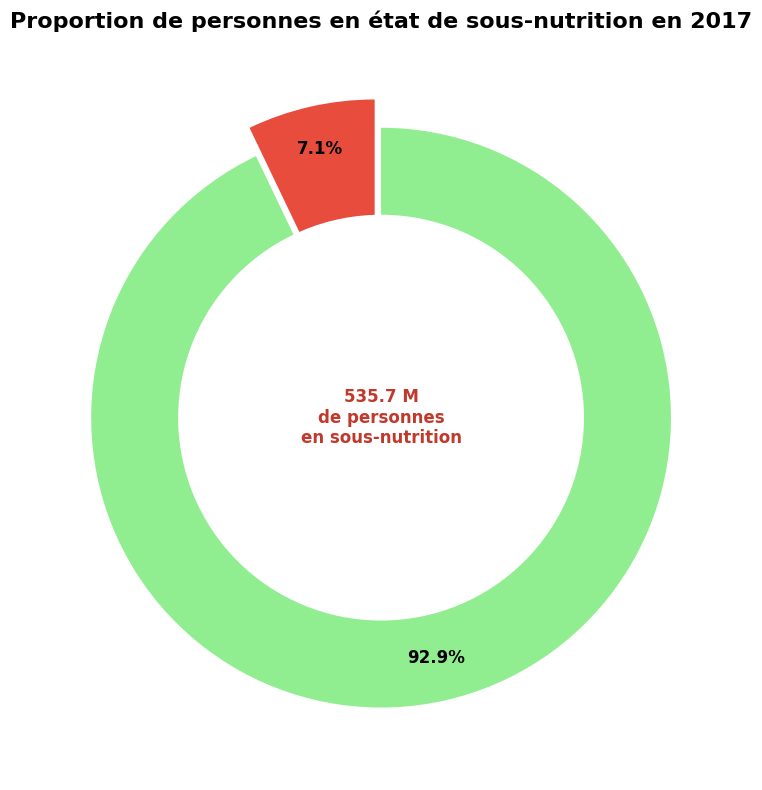

In [196]:
reste_population = nb_total - nb_sous_nutrition

labels = ['Sous-nutrition', 'Population nourrie']
sizes = [nb_sous_nutrition, reste_population]
# Rouge pour l'alerte, Vert clair pour la majorité
colors = ['#e74c3c', '#90ee90']

fig, ax = plt.subplots(figsize=(8, 8))

# Création du camembert (Donut)
# Explode permet de détacher légèrement la part rouge pour l'accentuer
wedges, texts, autotexts = ax.pie(sizes, autopct='%1.1f%%', startangle=90,
                                  colors=colors, pctdistance=0.85,
                                  explode=(0.1, 0))

# Customisation du texte des pourcentages
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')
    autotext.set_fontsize(12)

# Dessiner le cercle blanc au milieu
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Titre et mise en forme
plt.title("Proportion de personnes en état de sous-nutrition en 2017",
          fontsize=16, fontweight='bold', pad=20)

# Chiffre central pour l'impact
plt.text(0, 0, f"{nb_sous_nutrition/1000000:.1f} M\nde personnes\nen sous-nutrition",
         ha='center', va='center', fontsize=12, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()

# 2) Nombre théorique de personnes qui pourraient être nourries en 2017

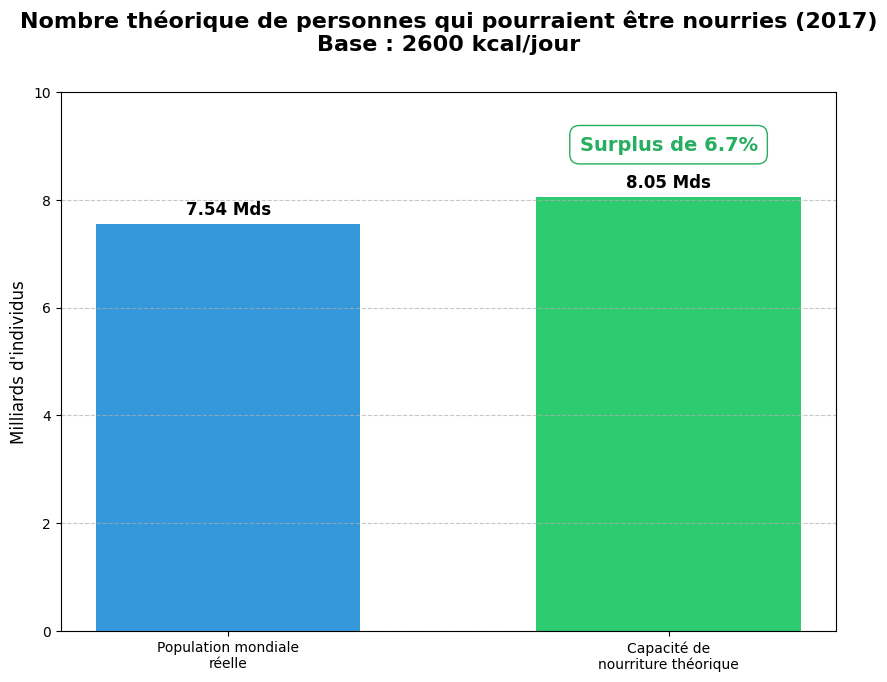

In [197]:
categories = ['Population mondiale\nréelle', 'Capacité de\nnourriture théorique']
valeurs = [nb_total/1000000000, humain_nourrissable/1000000000]

# Calcul du % d'évolution
evolution = ((humain_nourrissable - nb_total) / nb_total) * 100

# Création du graphique
plt.figure(figsize=(10, 7))
bars = plt.bar(categories, valeurs, color=['#3498db', '#2ecc71'], width=0.6)

# Ajout des étiquettes de données
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f} Mds', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Ajout de la flèche ou du texte d'évolution
plt.text(1, humain_nourrissable/1000000000 + 0.8 , f'Surplus de {evolution:.1f}%',
         ha='center', va='bottom', color='#27ae60', fontsize=14, fontweight='bold',
         bbox=dict(facecolor='none', edgecolor='#27ae60', boxstyle='round,pad=0.5'))

# Cosmétique
plt.ylabel('Milliards d\'individus', fontsize=12)
plt.title("Nombre théorique de personnes qui pourraient être nourries (2017)\nBase : 2600 kcal/jour",
          fontsize=16, fontweight='bold', pad=30)
plt.ylim(0, 10) # Pour laisser de la place au texte au-dessus
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 3) Nombre théorique de personnes qui pourraient être nourries uniquement avec les végétaux en 2017
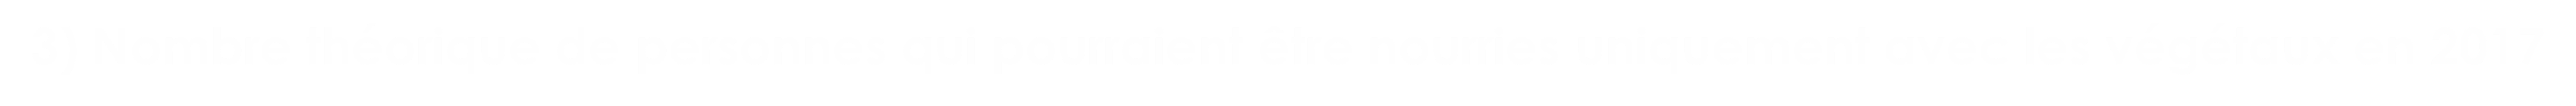
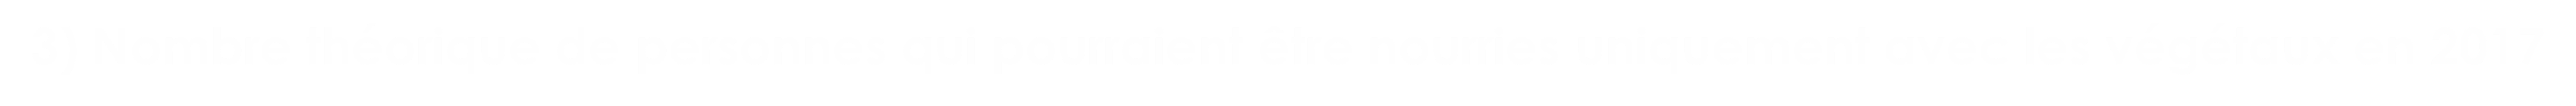
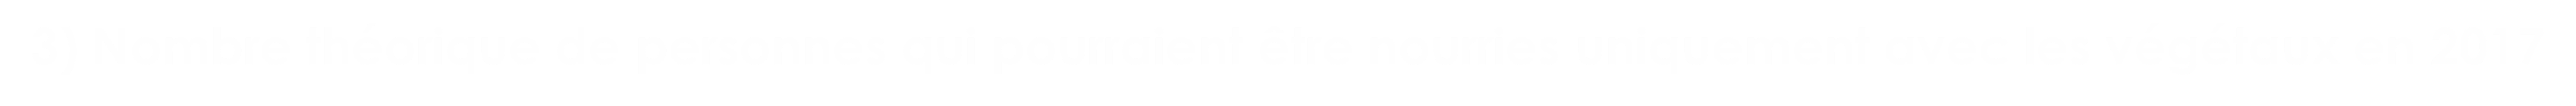
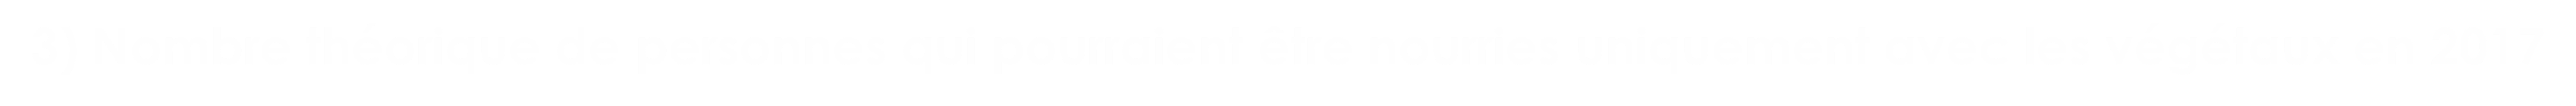

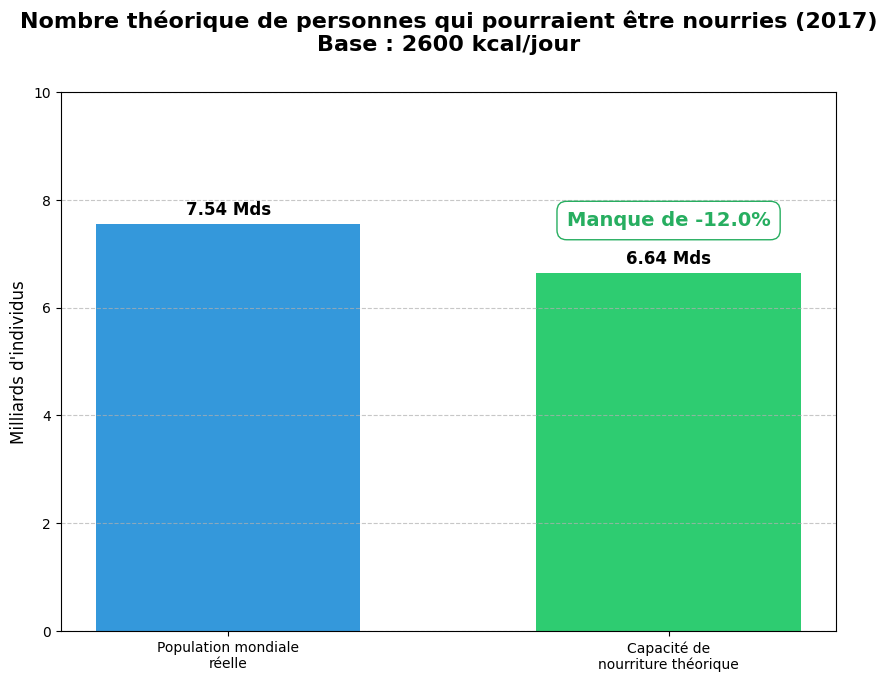

In [198]:
categories = ['Population mondiale\nréelle', 'Capacité de\nnourriture théorique']
valeurs = [nb_total/1000000000, humain_nourrissable_vege/1000000000]

# Calcul du % d'évolution
evolution = ((humain_nourrissable_vege - nb_total) / nb_total) * 100

# Création du graphique
plt.figure(figsize=(10, 7))
bars = plt.bar(categories, valeurs, color=['#3498db', '#2ecc71'], width=0.6)

# Ajout des étiquettes de données
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f} Mds', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Ajout de la flèche ou du texte d'évolution
plt.text(1, humain_nourrissable_vege/1000000000 + 0.8 , f'Manque de {evolution:.1f}%',
         ha='center', va='bottom', color='#27ae60', fontsize=14, fontweight='bold',
         bbox=dict(facecolor='none', edgecolor='#27ae60', boxstyle='round,pad=0.5'))

# Cosmétique
plt.ylabel('Milliards d\'individus', fontsize=12)
plt.title("Nombre théorique de personnes qui pourraient être nourries (2017)\nBase : 2600 kcal/jour",
          fontsize=16, fontweight='bold', pad=30)
plt.ylim(0, 10) # Pour laisser de la place au texte au-dessus
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 4) Répartition de la disponibilité intérieure

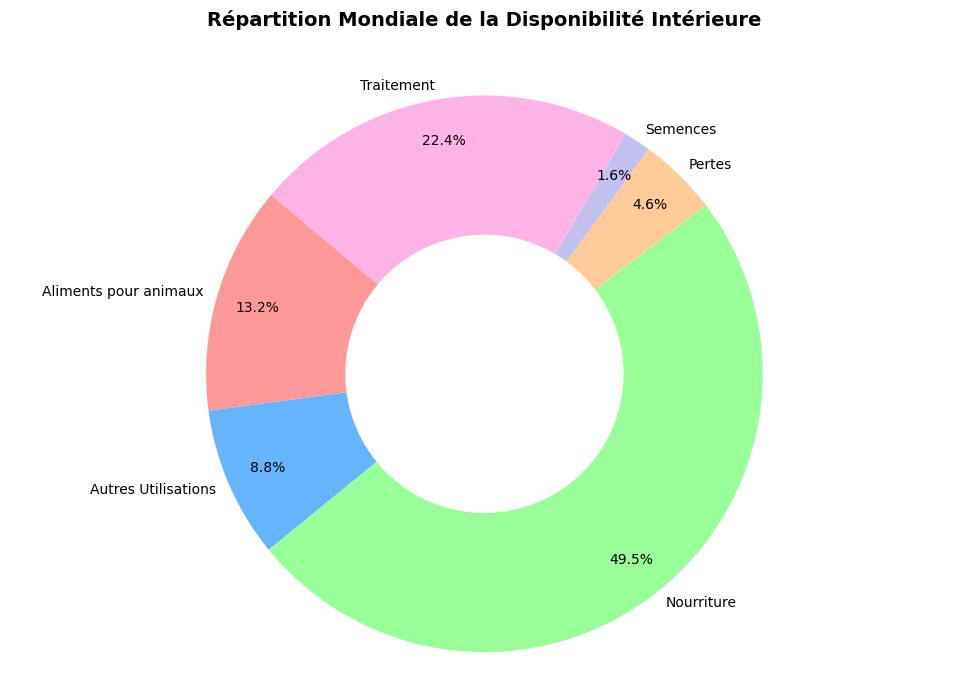

Le pourcentage dédié à l'alimentaire humaine est de : 49.46%


In [199]:
utilisations = [
    'Aliments pour animaux',
    'Autres Utilisations',
    'Nourriture',
    'Pertes',
    'Semences',
    'Traitement'
]

# 2. Calcul des totaux mondiaux
bilan_global = dispo_alimentaire[utilisations].sum()

# 3. Calcul du KPI d'Efficience (Nourriture / Total des utilisations)
total_utilisations = bilan_global.sum()
efficience = (bilan_global['Nourriture'] / total_utilisations) * 100

# 4. Affichage du graphique en Donut
plt.figure(figsize=(10, 7))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

plt.pie(bilan_global,
        labels=bilan_global.index,
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.85,
        colors=colors,
        labeldistance=1.05,
        radius=1)

# Cercle blanc au centre
centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(f"Répartition Mondiale de la Disponibilité Intérieure",
          fontsize=14, fontweight='bold',pad=30)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Le pourcentage dédié à l'alimentaire humaine est de : {efficience:.2f}%")

# 5) Part de l’utilisation des principales céréales entre l’alimentation humaine et animale

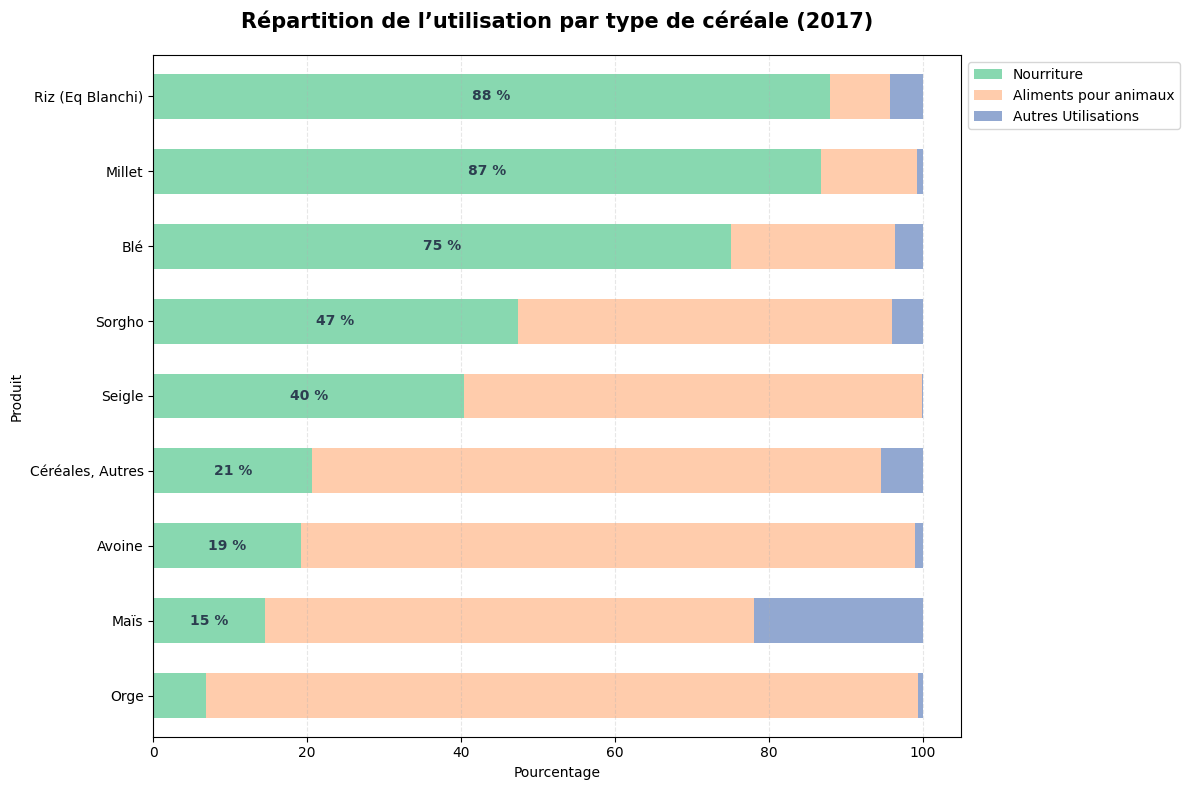

In [200]:
df = dispo_cereales.groupby('Produit')[['Disponibilité intérieure','Aliments pour animaux', 'Autres Utilisations', 'Nourriture']].sum()
cols = ["Aliments pour animaux", "Autres Utilisations", "Nourriture"]
df = df.drop(columns=["Disponibilité intérieure"])
df[cols] = df[cols].div(df[cols].sum(axis=1), axis=0) * 100
df = df[['Nourriture', 'Aliments pour animaux', 'Autres Utilisations']]
df = df.sort_values(by='Nourriture', ascending=False)
df.head(10)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#88D8B0', '#FFCCAC', '#92A8D1'] # Ta palette pastel contrastée

# 3. Construction des barres empilées
df.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.6)

# 4. Ajout des pourcentages à l'intérieur des barres (uniquement pour la partie Nourriture)
for i, (p, label) in enumerate(zip(ax.patches[:8], df['Nourriture'])):
    width = p.get_width()
    if width > 0.1: # On affiche si la barre est assez large
        ax.text(width/2, i, f'{label:.0f} %',
                va='center', ha='center', color='#2C3E50', fontweight='bold')

# 5. Cosmétique pour ressembler à ta pièce jointe
ax.set_title("Répartition de l’utilisation par type de céréale (2017)",
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("Pourcentage")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.gca().invert_yaxis() # Pour avoir le Riz en haut comme sur ton image
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 6) Liste des 10 pays où la proportion de personnes en état de sous-nutrition est la plus forte en 2017

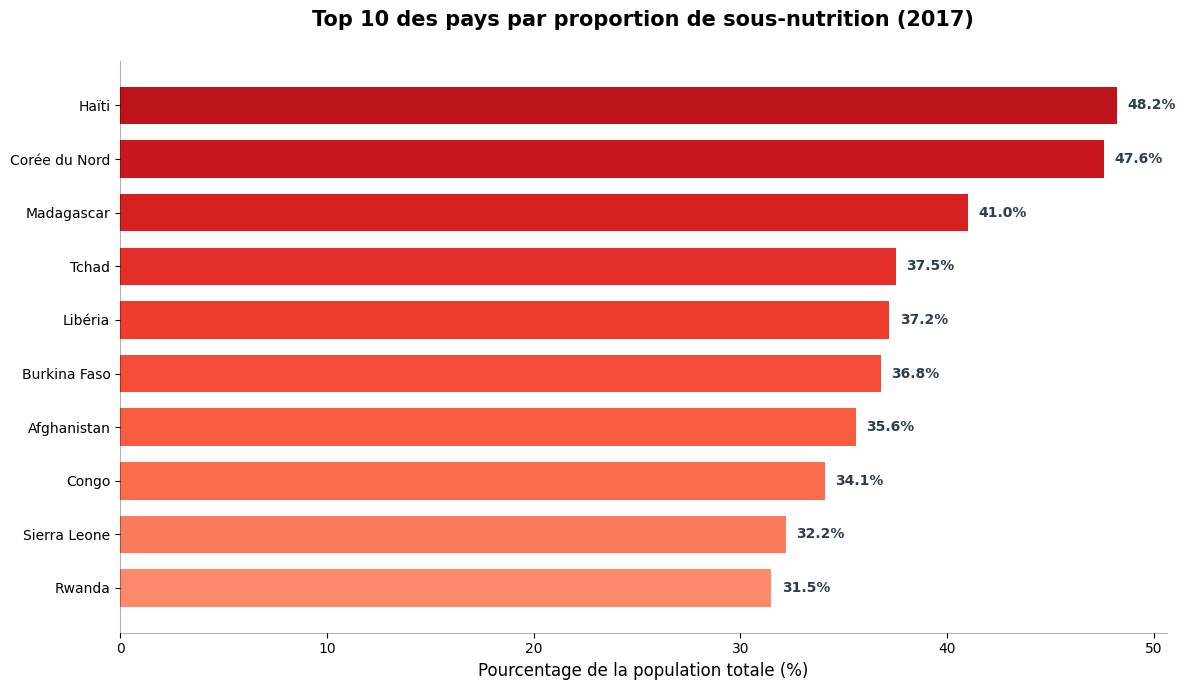

In [201]:
pays = [
    'Haïti', 'Corée du Nord', 'Madagascar', 'Tchad',
    'Libéria', 'Burkina Faso', 'Afghanistan',
    'Congo', 'Sierra Leone', 'Rwanda'
]
proportions = [48.2, 47.6, 41.0, 37.5, 37.2, 36.8, 35.6, 34.1, 32.2, 31.5]

# Création de la nuance de rouge avec .Reds
colors = cm.Reds(np.linspace(0.8, 0.4, len(pays)))
# Création du graphique
plt.figure(figsize=(12, 7))
bars = plt.barh(pays, proportions, color=colors, height=0.7)

# Ajout des chiffres au bout de chaque barre
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width}%', va='center', fontweight='bold', color='#2C3E50')

# Inverser l'axe pour avoir le plus critique en haut
plt.gca().invert_yaxis()

# Cosmétique
plt.title("Top 10 des pays par proportion de sous-nutrition (2017)",
          fontsize=15, fontweight='bold', pad=25)
plt.xlabel("Pourcentage de la population totale (%)", fontsize=12)

# Suppression des lignes inutiles pour un look épuré
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_alpha(0.3)
plt.gca().spines['left'].set_alpha(0.3)

plt.tight_layout()
plt.show()

# 7) Liste des 10 pays qui ont le plus bénéficié de l’aide alimentaire entre 2013 et 2016

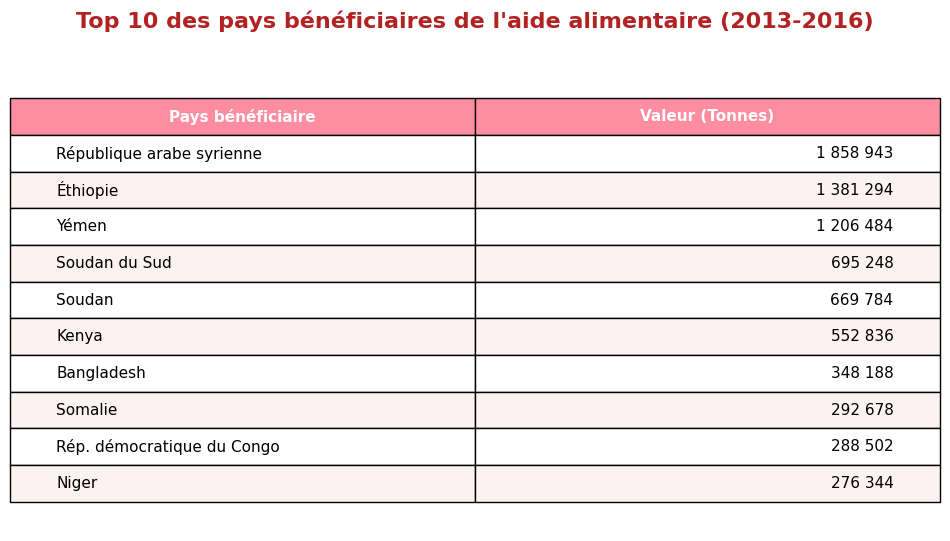

In [202]:
data = [
    ["République arabe syrienne", "1 858 943"],
    ["Éthiopie", "1 381 294"],
    ["Yémen", "1 206 484"],
    ["Soudan du Sud", "695 248"],
    ["Soudan", "669 784"],
    ["Kenya", "552 836"],
    ["Bangladesh", "348 188"],
    ["Somalie", "292 678"],
    ["Rép. démocratique du Congo", "288 502"],
    ["Niger", "276 344"]
]
column_labels = ["Pays bénéficiaire", "Valeur (Tonnes)"]

# Création de la figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

# Création du tableau
table = ax.table(cellText=data, colLabels=column_labels, loc='center', cellLoc='left')

# Style du tableau
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

# Coloration (Rouge pour l'urgence / Gris pour la lecture)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#FF8DA1')
        cell.set_text_props(ha='center')
    elif row % 2 == 0:
        cell.set_facecolor('#FDF2F2') #
    else:
        cell.set_facecolor('white')

    # Alignement spécifique pour les chiffres à droite
    if col == 1 and row != 0:
        cell.set_text_props(ha='right')

plt.title("Top 10 des pays bénéficiaires de l'aide alimentaire (2013-2016)",
          fontsize=16, fontweight='bold', pad=30, color='#B22222')

plt.show()

# 8) Évolution de l’aide alimentaire pour les 5 pays qui en ont le plus bénéficié entre 2013 et 2016

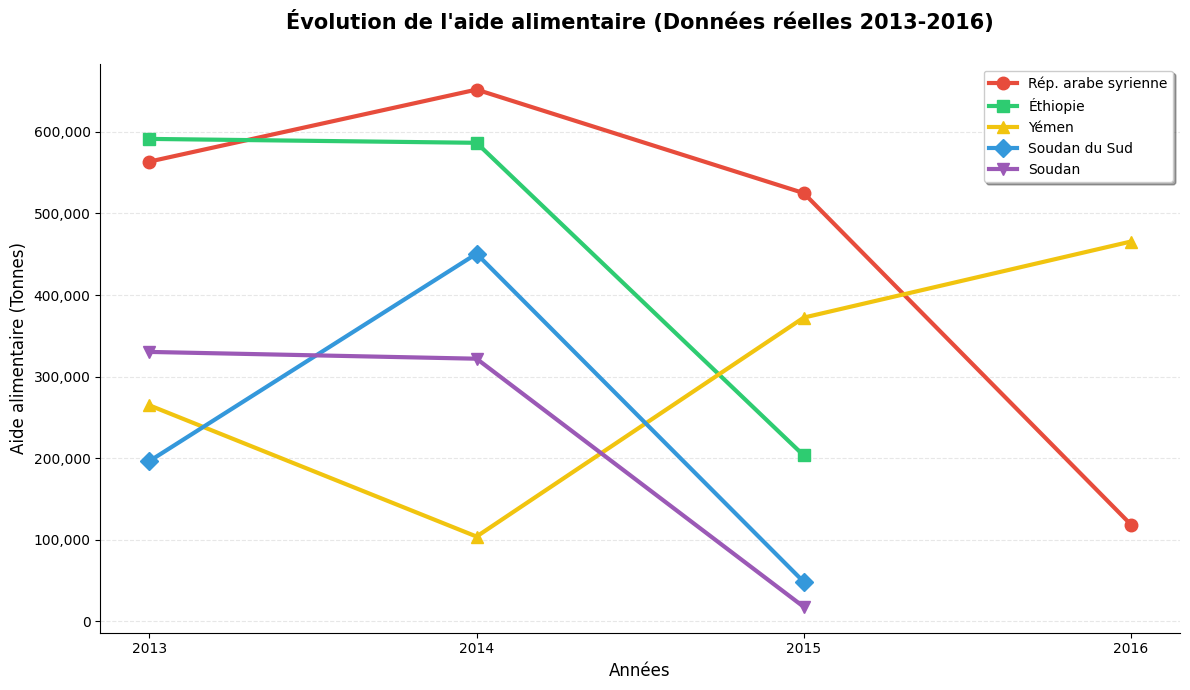

In [203]:
annees = [2013, 2014, 2015, 2016]

# Utilisation de np.nan pour les données manquantes
donnees = {
    'Rép. arabe syrienne': [563566, 651870, 524949, 118558],
    'Éthiopie': [591404, 586624, 203266, np.nan],
    'Yémen': [264764, 103840, 372306, 465574],
    'Soudan du Sud': [196330, 450610, 48308, np.nan],
    'Soudan': [330230, 321904, 17650, np.nan]
}

# Configuration graphique
plt.figure(figsize=(12, 7))
couleurs = ['#E74C3C', '#2ECC71', '#F1C40F', '#3498DB', '#9B59B6']
marqueurs = ['o', 's', '^', 'D', 'v']

for i, (pays, valeurs) in enumerate(donnees.items()):
    # Trace la ligne
    plt.plot(annees, valeurs,
             label=pays,
             color=couleurs[i],
             marker=marqueurs[i],
             linewidth=3,
             markersize=9,
             linestyle='-')

# 3. Cosmétique et lisibilité
plt.title("Évolution de l'aide alimentaire (Données réelles 2013-2016)",
          fontsize=15, fontweight='bold', pad=25)
plt.ylabel("Aide alimentaire (Tonnes)", fontsize=12)
plt.xlabel("Années", fontsize=12)
plt.xticks(annees)

# Formatage des nombres sur l'axe Y (milliers)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=True, shadow=True)

# Nettoyage
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 9.1) Liste des 10 pays qui ont la plus forte disponibilité alimentaire par habitant

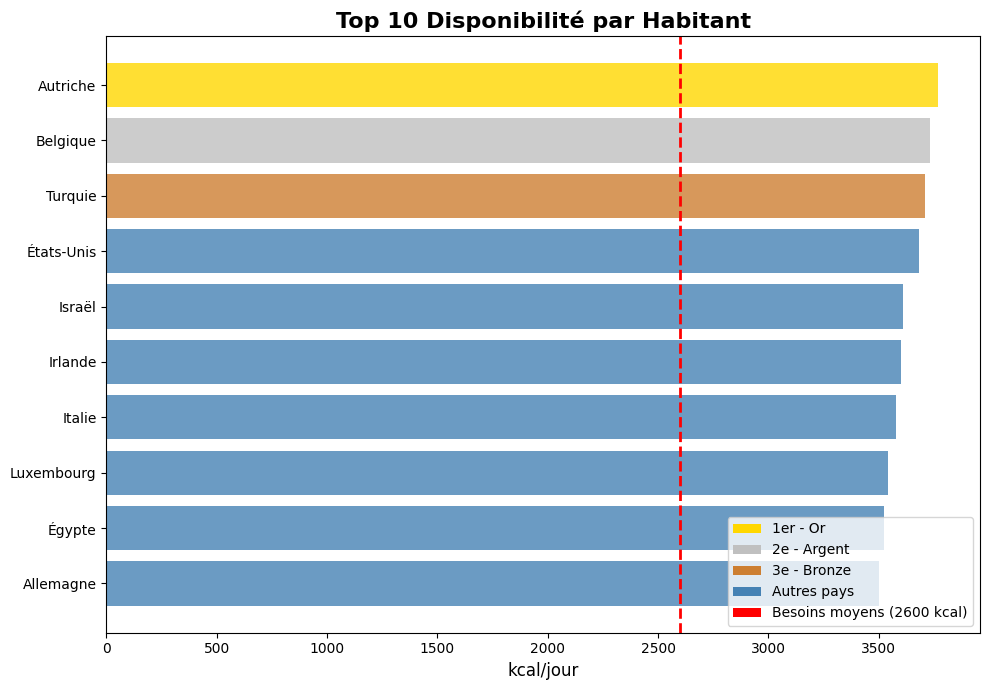

In [204]:
from matplotlib.patches import Patch

pays = ["Belgique", "Autriche", "Turquie", "États-Unis", "Israël",
        "Irlande", "Italie", "Luxembourg", "Égypte", "Allemagne"]
kcal = [3730, 3770, 3708, 3682, 3610, 3602, 3578, 3540, 3522, 3503]

sorted_data = sorted(zip(kcal, pays), reverse=True)  # trie par kcal
kcal_sorted, pays_sorted = zip(*sorted_data)

# Couleurs : podium et reste
colors = []
for country in pays_sorted:
    if country == "Autriche":
        colors.append('#FFD700')  # Or
    elif country == "Belgique":
        colors.append('#C0C0C0')  # Argent
    elif country == "Turquie":
        colors.append('#CD7F32')  # Bronze
    else:
        colors.append('#4682B4')  # Bleu pour les autres

# 4. Création du graphique
plt.figure(figsize=(10, 7))
plt.barh(pays_sorted[::-1], kcal_sorted[::-1], color=colors[::-1], alpha=0.8)  # <-- inverser les couleurs

# Ligne rouge de référence
plt.axvline(x=2600, color='red', linestyle='--', linewidth=2)

# Labels et titre
plt.xlabel("kcal/jour", fontsize=12)
plt.title("Top 10 Disponibilité par Habitant", fontsize=16, fontweight='bold')

# Légende manuelle pour le podium
legend_elements = [
    Patch(facecolor='#FFD700', label='1er - Or'),
    Patch(facecolor='#C0C0C0', label='2e - Argent'),
    Patch(facecolor='#CD7F32', label='3e - Bronze'),
    Patch(facecolor='#4682B4', label='Autres pays'),
    Patch(facecolor='red', label='Besoins moyens (2600 kcal)', linestyle='--')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# 9.2) Liste des 10 pays qui ont la plus faible disponibilité alimentaire par habitant

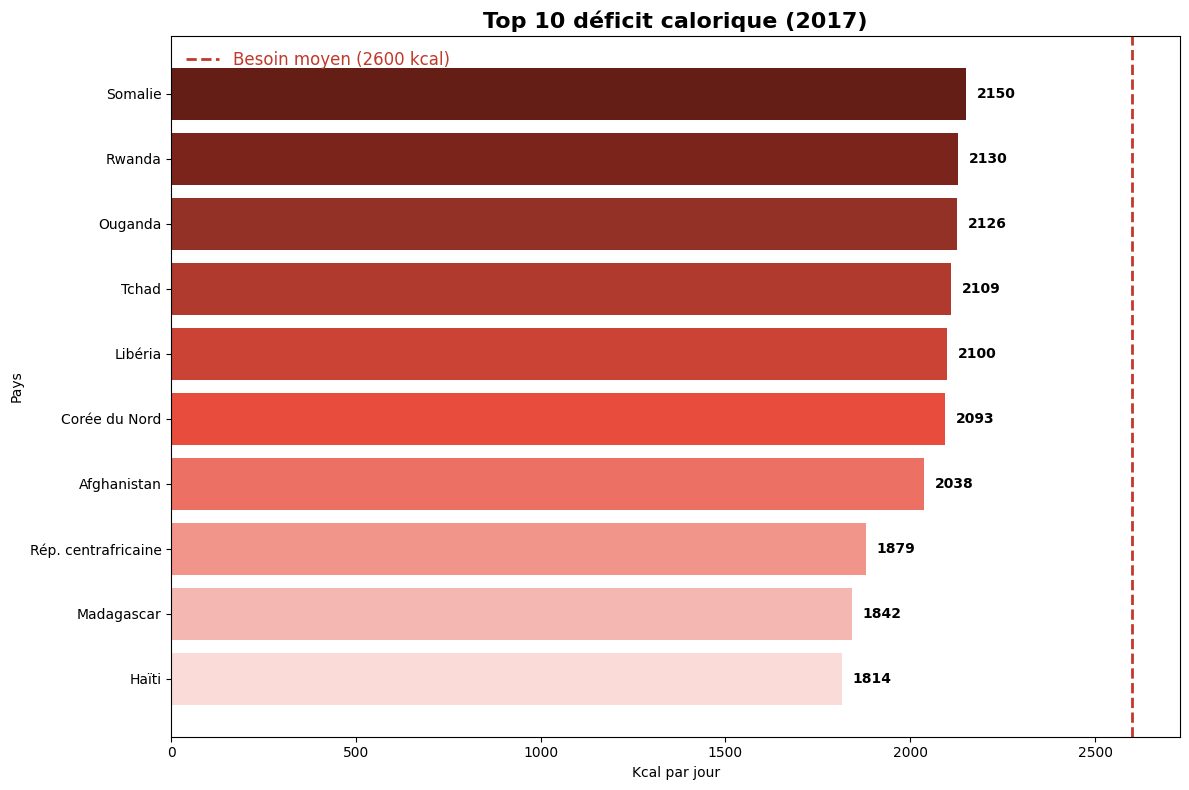

In [205]:
pays = ["Haïti", "Rép. centrafricaine", "Madagascar", "Afghanistan", "Corée du Nord",
        "Libéria", "Tchad", "Ouganda", "Rwanda", "Somalie"]
kcal = [1814, 1879, 1842, 2038, 2093, 2100, 2109, 2126, 2130, 2150]

# Palette de rouges
colors_list = ['#FADBD8', '#F5B7B1', '#F1948A', '#EC7063', '#E74C3C',
               '#CB4335', '#B03A2E', '#943126', '#7B241C', '#641E16']

# Trier les données par kcal croissant
sorted_indices = np.argsort(kcal)  # du plus faible au plus élevé
pays_sorted = [pays[i] for i in sorted_indices]
kcal_sorted = [kcal[i] for i in sorted_indices]
colors_sorted = [colors_list[i] for i in range(len(kcal_sorted))]  # plus faible = clair, plus élevé = foncé

# Créer figure
plt.figure(figsize=(12, 8))
bars = plt.barh(pays_sorted, kcal_sorted, color=colors_sorted)

# Ligne de référence
plt.axvline(x=2600, color='#C0392B', linestyle='--', linewidth=2, label='Besoin moyen (2600 kcal)')

# Ajouter valeurs à droite des barres
for bar in bars:
    width = bar.get_width()
    plt.text(width + 30, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             va='center', fontweight='bold')

# Titres et labels
plt.title("Top 10 déficit calorique (2017)", fontsize=16, fontweight='bold')
plt.xlabel("Kcal par jour")
plt.ylabel("Pays")

# Légende
plt.legend(frameon=False, fontsize=12, labelcolor='#C0392B')

plt.tight_layout()
plt.show()

# 10) Étude sur le manioc en Thaïlande

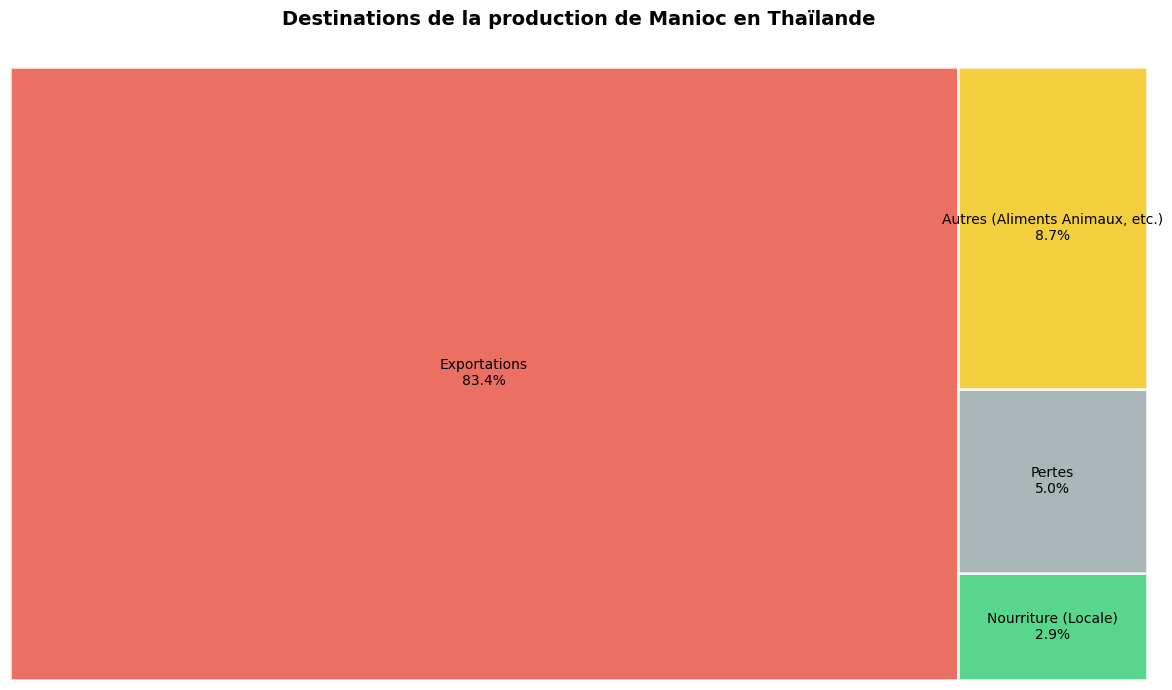

La Thaïlande exporte 83.4% de sa production de Manioc.


In [206]:
import squarify

# 1. Extraction des données pour le Manioc en Thaïlande
df_thai = dispo_alimentaire[(dispo_alimentaire['Zone'] == 'Thaïlande') & (dispo_alimentaire['Produit'] == 'Manioc')]

# Préparation des données pour le Treemap
labels_raw = ['Exportations', 'Nourriture (Locale)', 'Pertes', 'Autres (Aliments Animaux, etc.)']
export = df_thai['Exportations - Quantité'].values[0]
nourriture = df_thai['Nourriture'].values[0]
pertes = df_thai['Pertes'].values[0]
autres = df_thai['Production'].values[0] - (export + nourriture + pertes)

volumes = [export, nourriture, pertes, autres]

# Création des labels avec les pourcentages pour que ce soit clair
pct = [100*v/sum(volumes) for v in volumes]
labels = [f"{l}\n{p:.1f}%" for l, p in zip(labels_raw, pct)]

# 2. Création du Treemap
plt.figure(figsize=(12, 7))

# Palette : Rouge pour l'export, Vert pour la nourriture, Gris pour le reste
colors = ['#e74c3c', '#2ecc71', '#95a5a6', '#f1c40f']

squarify.plot(sizes=volumes, label=labels, color=colors, alpha=0.8, edgecolor="white", linewidth=2)

# 3. Titre en question comme convenu
plt.title("Destinations de la production de Manioc en Thaïlande",
          fontsize=14, fontweight='bold', pad=30)

plt.axis('off')
plt.tight_layout()
plt.show()

print(f"La Thaïlande exporte {pct[0]:.1f}% de sa production de Manioc.")

Environ 9% en sous-nutrition, 6.5 millions de personne
Disponibilité intérieure au-dessus du besoin moyen, environ 2600 kcal